In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('creditcard.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
from sklearn.model_selection import train_test_split


In [7]:
X = df.drop('Class', axis=1)
y = df['Class']

In [8]:
X_train , X_test, y_train , y_test = train_test_split(
    X,y, test_size=0.2, random_state=42 , stratify=y    
    )

In [10]:
from sklearn.tree  import DecisionTreeClassifier

In [11]:
model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=50,
    class_weight='balanced',
    random_state=42
)

In [12]:
model.fit(X_train, y_train  )

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,50
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [13]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import confusion_matrix , classification_report

In [20]:
print("Matrix : " , confusion_matrix(y_test, y_pred)  )
print("-------------------------")
print("Report : \n" , classification_report(y_test, y_pred)  )

Matrix :  [[55525  1339]
 [   15    83]]
-------------------------
Report : 
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.85      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.91      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [24]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [27]:
from sklearn.metrics import roc_curve, roc_auc_score

In [30]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1] 

In [31]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

In [32]:
print("AUC Score:", auc_score)

AUC Score: 0.8927062278203346


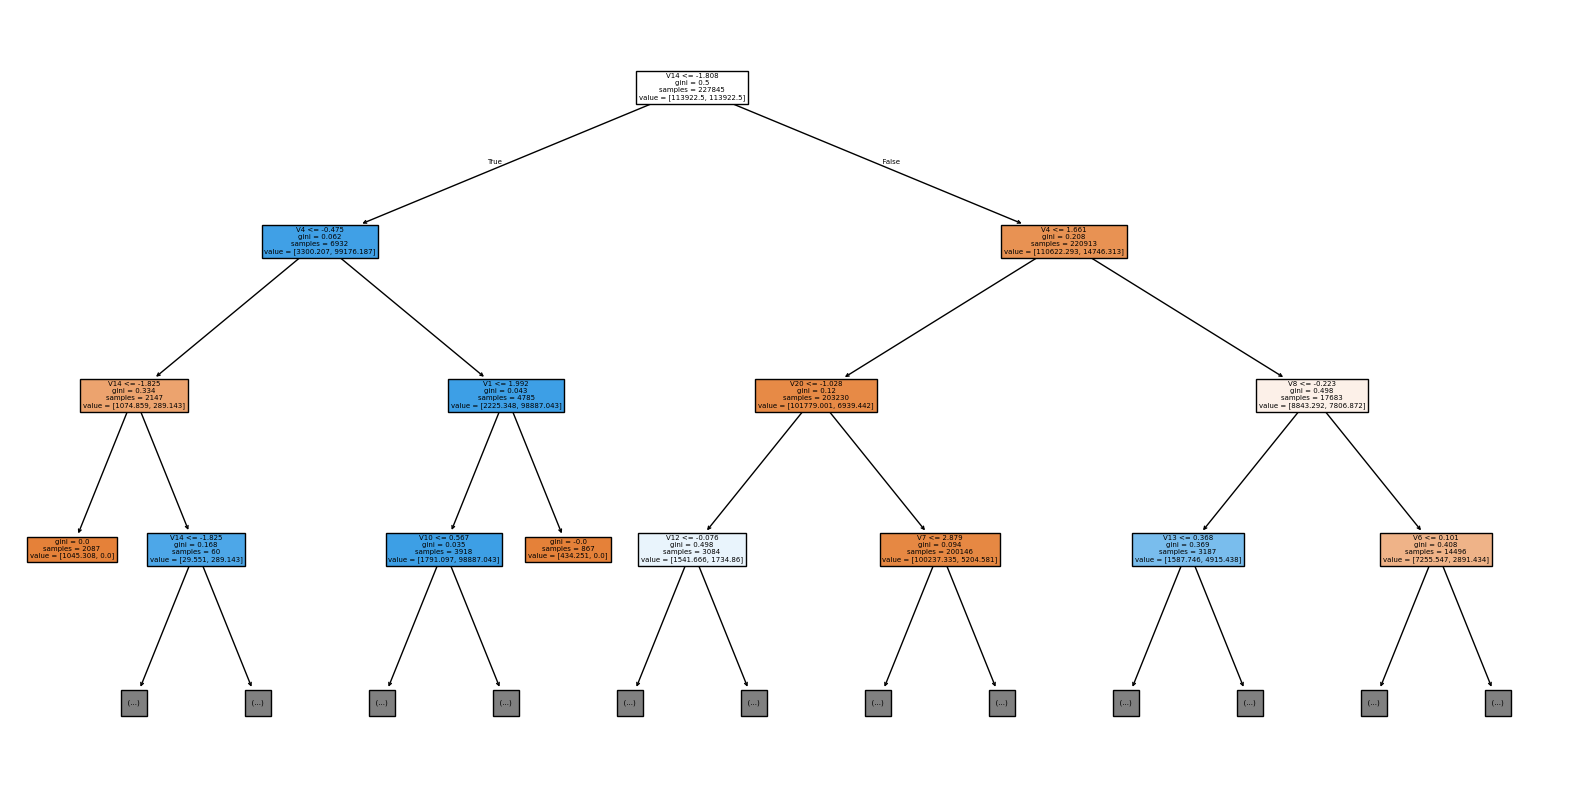

In [34]:
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, filled=True, max_depth=3)
plt.show()

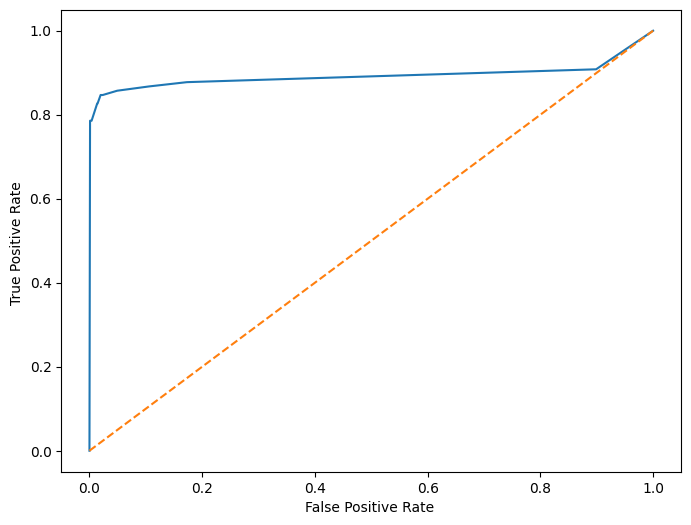

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"Decision Tree (AUC = {auc_score:.4f})")
plt.plot([0,1], [0,1], linestyle="--")  
plt.xlabel("False Positive Rate ")
plt.ylabel("True Positive Rate ")
plt.show()